In [17]:
import os

In [18]:
import pandas as pd
df = pd.read_csv(
"arrhythmia.csv",
header=None,
na_values="?"
)
print("Raw shape:", df.shape)
print(df.head())

Raw shape: (452, 280)
   0    1    2    3    4    5    6    7    8    9    ...  270   271  272  273  \
0   75    0  190   80   91  193  371  174  121  -16  ...  0.0   9.0 -0.9  0.0   
1   56    1  165   64   81  174  401  149   39   25  ...  0.0   8.5  0.0  0.0   
2   54    0  172   95  138  163  386  185  102   96  ...  0.0   9.5 -2.4  0.0   
3   55    0  175   94  100  202  380  179  143   28  ...  0.0  12.2 -2.2  0.0   
4   75    0  190   80   88  181  360  177  103  -16  ...  0.0  13.1 -3.6  0.0   

   274  275  276   277   278  279  
0  0.0  0.9  2.9  23.3  49.4    8  
1  0.0  0.2  2.1  20.4  38.8    6  
2  0.0  0.3  3.4  12.3  49.0   10  
3  0.0  0.4  2.6  34.6  61.6    1  
4  0.0 -0.1  3.9  25.4  62.8    7  

[5 rows x 280 columns]


In [19]:
df.columns = [
"age", "sex", "height", "weight",
"qrs_duration", "pr_interval", "qt_interval",
"t_interval", "p_interval", "qrs_angle",
"t_angle", "p_angle", "qrst_angle",
"j_angle", "heart_rate"
] + list(df.columns[15:-1]) + ["class"]
print(df.columns[:15])
print(df.columns[-3:])
print(df.head())

Index(['age', 'sex', 'height', 'weight', 'qrs_duration', 'pr_interval',
       'qt_interval', 't_interval', 'p_interval', 'qrs_angle', 't_angle',
       'p_angle', 'qrst_angle', 'j_angle', 'heart_rate'],
      dtype='object')
Index([277, 278, 'class'], dtype='object')
   age  sex  height  weight  qrs_duration  pr_interval  qt_interval  \
0   75    0     190      80            91          193          371   
1   56    1     165      64            81          174          401   
2   54    0     172      95           138          163          386   
3   55    0     175      94           100          202          380   
4   75    0     190      80            88          181          360   

   t_interval  p_interval  qrs_angle  ...  270   271  272  273  274  275  276  \
0         174         121        -16  ...  0.0   9.0 -0.9  0.0  0.0  0.9  2.9   
1         149          39         25  ...  0.0   8.5  0.0  0.0  0.0  0.2  2.1   
2         185         102         96  ...  0.0   9.5 -2.4  0.

In [20]:
df.columns = [
"age", "sex", "height", "weight",
"qrs_duration", "pr_interval", "qt_interval",
"t_interval", "p_interval", "qrs_angle",
"t_angle", "p_angle", "qrst_angle",
"j_angle", "heart_rate"
] + list(df.columns[15:-1]) + ["class"]
print(df.columns[:15])
print(df.columns[-3:])
print(df.head())

Index(['age', 'sex', 'height', 'weight', 'qrs_duration', 'pr_interval',
       'qt_interval', 't_interval', 'p_interval', 'qrs_angle', 't_angle',
       'p_angle', 'qrst_angle', 'j_angle', 'heart_rate'],
      dtype='object')
Index([277, 278, 'class'], dtype='object')
   age  sex  height  weight  qrs_duration  pr_interval  qt_interval  \
0   75    0     190      80            91          193          371   
1   56    1     165      64            81          174          401   
2   54    0     172      95           138          163          386   
3   55    0     175      94           100          202          380   
4   75    0     190      80            88          181          360   

   t_interval  p_interval  qrs_angle  ...  270   271  272  273  274  275  276  \
0         174         121        -16  ...  0.0   9.0 -0.9  0.0  0.0  0.9  2.9   
1         149          39         25  ...  0.0   8.5  0.0  0.0  0.0  0.2  2.1   
2         185         102         96  ...  0.0   9.5 -2.4  0.

In [21]:
df_original = df.copy(deep=True)
print("Records:", df_original.shape[0])
print("Columns:", df_original.shape[1])
print("\nData-type counts:")
print(df_original.dtypes.value_counts())
df_original.info()
print("\nSummary of numeric columns:")
print(df_original.describe())

Records: 452
Columns: 280

Data-type counts:
int64      155
float64    125
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Columns: 280 entries, age to class
dtypes: float64(125), int64(155)
memory usage: 988.9 KB

Summary of numeric columns:
              age         sex      height      weight  qrs_duration  \
count  452.000000  452.000000  452.000000  452.000000    452.000000   
mean    46.471239    0.550885  166.188053   68.170354     88.920354   
std     16.466631    0.497955   37.170340   16.590803     15.364394   
min      0.000000    0.000000  105.000000    6.000000     55.000000   
25%     36.000000    0.000000  160.000000   59.000000     80.000000   
50%     47.000000    1.000000  164.000000   68.000000     86.000000   
75%     58.000000    1.000000  170.000000   79.000000     94.000000   
max     83.000000    1.000000  780.000000  176.000000    188.000000   

       pr_interval  qt_interval  t_interval  p_interval   qrs_angle  ...  \
co

In [22]:
# Missing values
missing = df_original.isna().sum()
print("Columns containing missing values:")
print(missing[missing > 0].sort_values(ascending=False))
# Duplicate rows
print("\nNumber of duplicate rows:")
print(df_original.duplicated().sum())
# Important ranges
range_cols = ["age", "height", "weight", "heart_rate"]
print("\nMinimum and maximum values:")
print(df_original[range_cols].agg(["min", "max"]))
# Diagnosis distribution
print("\nPatients per diagnosis class:")
print(df_original["class"].value_counts().sort_index())

review_cols = ["age", "sex", "height", "weight", "class"]
records_to_review = df_original.loc[
(df_original["age"] < 18)
| (df_original["height"] < 120)
| (df_original["height"] > 220)
| (df_original["weight"] < 25),
review_cols
].sort_values(["age", "height", "weight"])
records_to_review = records_to_review.copy()
records_to_review["bmi"] = (
records_to_review["weight"]
/ (records_to_review["height"] / 100) ** 2
)
print(records_to_review.round(2).to_string())

Columns containing missing values:
j_angle       376
p_angle        22
t_angle         8
qrst_angle      1
heart_rate      1
dtype: int64

Number of duplicate rows:
0

Minimum and maximum values:
     age  height  weight  heart_rate
min    0     105       6        44.0
max   83     780     176       163.0

Patients per diagnosis class:
class
1     245
2      44
3      15
4      15
5      13
6      25
7       3
8       2
9       9
10     50
14      4
15      5
16     22
Name: count, dtype: int64
     age  sex  height  weight  class    bmi
316    0    0     608      10      5   0.27
60     1    0     110      10      5   8.26
141    1    1     780       6      5   0.10
320    3    0     105      12      5  10.88
424    7    0     119      21      9  14.83
403    7    1     127      22      5  13.64
297    7    1     130      30     10  17.75
379    8    0     120      28     10  19.44
429    8    1     130      24     16  14.20
401    9    0     120      25     14  17.36
113    9    0   

In [23]:
def clean_data(data):
    clean = data.copy(deep=True)
    clean["sex"] = clean["sex"].replace({"M": 0, "F": 1, "m": 0, "f": 1})
    clean["bmi"] = clean["weight"] / (clean["height"] / 100) ** 2

    invalid_record = (
        (clean["height"] > 250)
        | ((clean["age"] <= 1) & (clean["height"] > 100))
        | ((clean["age"] >= 20) & (clean["bmi"] < 10))
    )

    print("Clearly unreliable records removed:")
    print(
        clean.loc[
            invalid_record,
            ["age", "sex", "height", "weight", "bmi", "class"]
        ].round(2)
    )

    clean = clean.loc[~invalid_record].copy()
    clean["bmi"] = clean["weight"] / (clean["height"] / 100) ** 2

    for col in ["p_angle", "t_angle", "qrst_angle", "heart_rate"]:
        clean[col] = clean[col].fillna(clean[col].median())

    clean = clean.drop(columns=["j_angle"], errors="ignore")
    clean = clean.drop_duplicates()
    clean["arrhythmia_present"] = clean["class"] != 1
    clean = clean.reset_index(drop=True)
    return clean


In [24]:
df_etl_clean = clean_data(df_original)

print("Original shape:", df_original.shape)
print("Cleaned shape:", df_etl_clean.shape)
print("Rows removed:", len(df_original) - len(df_etl_clean))
print("\nCleaned demographic ranges:")
print(df_etl_clean[["age", "height", "weight", "bmi"]].agg(["min", "max"]))
print("Heights above 250 cm:", (df_etl_clean["height"] > 250).sum())
print(
    "Adults with BMI below 10:",
    ((df_etl_clean["age"] >= 20) & (df_etl_clean["bmi"] < 10)).sum(),
)
print("Duplicate rows:", df_etl_clean.duplicated().sum())
print("j_angle still present:", "j_angle" in df_etl_clean.columns)


Clearly unreliable records removed:
     age  sex  height  weight   bmi  class
60     1    0     110      10  8.26      5
126   58    0     186      18  5.20      1
141    1    1     780       6  0.10      5
316    0    0     608      10  0.27      5
Original shape: (452, 280)
Cleaned shape: (448, 281)
Rows removed: 4

Cleaned demographic ranges:
     age  height  weight        bmi
min    3     105      12  10.884354
max   83     190     176  61.622492
Heights above 250 cm: 0
Adults with BMI below 10: 0
Duplicate rows: 0
j_angle still present: False


In [25]:
import sqlite3
# ETL: transform first, then load
with sqlite3.connect("etl.db") as conn:
    df_etl_clean.to_sql(
"clean",
conn,
if_exists="replace",
index=False
)
# ELT: load raw first, then transform
with sqlite3.connect("elt.db") as conn:
    df_original.to_sql(
"raw",
conn,
if_exists="replace",
index=False
)
df_elt_raw = pd.read_sql(
"SELECT * FROM raw",
conn
)
df_elt_clean = clean_data(df_elt_raw)
df_elt_clean.to_sql(
"clean",
conn,
if_exists="replace",
index=False
)
print("ETL clean shape:", df_etl_clean.shape)
print("ELT raw shape:", df_elt_raw.shape)
print("ELT clean shape:", df_elt_clean.shape)

Clearly unreliable records removed:
     age  sex  height  weight   bmi  class
60     1    0     110      10  8.26      5
126   58    0     186      18  5.20      1
141    1    1     780       6  0.10      5
316    0    0     608      10  0.27      5
ETL clean shape: (448, 281)
ELT raw shape: (452, 280)
ELT clean shape: (448, 281)


In [26]:
with sqlite3.connect("etl.db") as conn:
    print("Tables in etl.db:")
print(pd.read_sql(
"SELECT name FROM sqlite_master "
"WHERE type='table'",
conn
))
with sqlite3.connect("elt.db") as conn:
    print("\nTables in elt.db:")
    print(pd.read_sql(
"SELECT name FROM sqlite_master "
"WHERE type='table'",
conn
))
 # Series versus DataFrame
print(df_original["heart_rate"].mean())
print(
df_original[
["heart_rate", "age"]
].mean()
)
import time
# Slow method: loop
start = time.time()
slow_result = []
for i in range(len(df_original)):
    slow_result.append(
df_original["weight"].iloc[i] / df_original["height"].iloc[i]
)
slow_time = time.time() - start
# Fast method: vectorised calculation
start = time.time()
fast_result = df_original["weight"] / df_original["height"]
fast_time = time.time() - start
# Compare the first five results
print("Slow result:")
print(slow_result[:5])
print("\nFast result:")
print(fast_result.head().tolist())
# Compare the speed
print("\nSlow time:", slow_time)
print("Fast time:", fast_time)
if fast_time == 0 or slow_time == 0:
    print("\nFast method was too fast to measure reliably; ratio is undefined.")
else:
    print("\nFast method is", slow_time / fast_time, "times faster")
# Shape and data types
print(df_original.shape)
print(df_original.dtypes.value_counts())
df_original.info()


Tables in etl.db:
    name
0  clean

Tables in elt.db:
    name
0    raw
1  clean
74.46341463414635
heart_rate    74.463415
age           46.471239
dtype: float64
Slow result:
[np.float64(0.42105263157894735), np.float64(0.3878787878787879), np.float64(0.5523255813953488), np.float64(0.5371428571428571), np.float64(0.42105263157894735)]

Fast result:
[0.42105263157894735, 0.3878787878787879, 0.5523255813953488, 0.5371428571428571, 0.42105263157894735]

Slow time: 0.01330423355102539
Fast time: 0.0

Fast method was too fast to measure reliably; ratio is undefined.
(452, 280)
int64      155
float64    125
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Columns: 280 entries, age to class
dtypes: float64(125), int64(155)
memory usage: 988.9 KB


In [27]:
summary_cols = ["age", "height", "weight", "heart_rate"]

print(df_etl_clean[summary_cols].describe())
skew_results = (
    df_etl_clean[summary_cols]
    .skew()
    .round(2)
)
print(skew_results)
print(
    df_etl_clean["arrhythmia_present"]
    .value_counts(normalize=True)
)
print("Minimum age retained:", df_etl_clean["age"].min())
print("Minimum weight retained:", df_etl_clean["weight"].min())

              age      height      weight  heart_rate
count  448.000000  448.000000  448.000000  448.000000
mean    46.752232  163.912946   68.680804   74.062500
std     16.097125   10.065291   15.749248   12.844296
min      3.000000  105.000000   12.000000   44.000000
25%     36.000000  160.000000   59.750000   65.000000
50%     47.000000  164.000000   68.000000   72.000000
75%     58.250000  170.000000   79.000000   81.000000
max     83.000000  190.000000  176.000000  124.000000
age          -0.21
height       -1.24
weight        0.54
heart_rate    0.83
dtype: float64
arrhythmia_present
False    0.544643
True     0.455357
Name: proportion, dtype: float64
Minimum age retained: 3
Minimum weight retained: 12


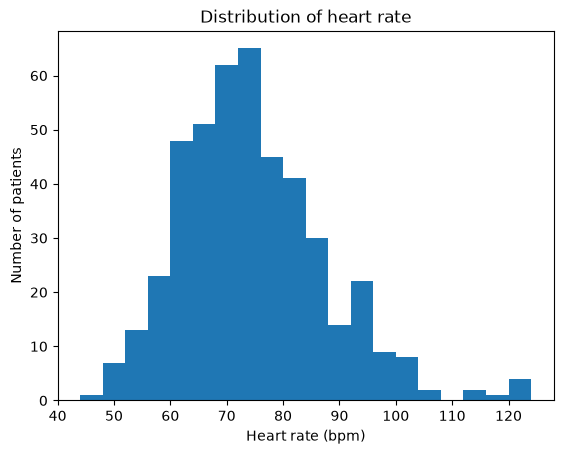

In [28]:
import matplotlib.pyplot as plt

# Cleaned-data distributions
plt.hist(df_etl_clean["heart_rate"].dropna(), bins=20)
plt.xlabel("Heart rate (bpm)")
plt.ylabel("Number of patients")
plt.title("Distribution of heart rate")
plt.show()

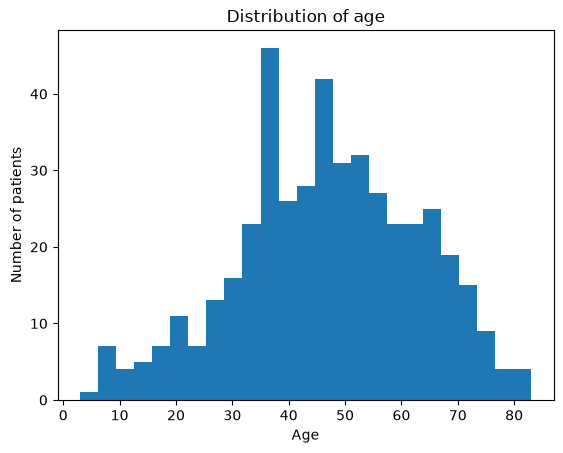

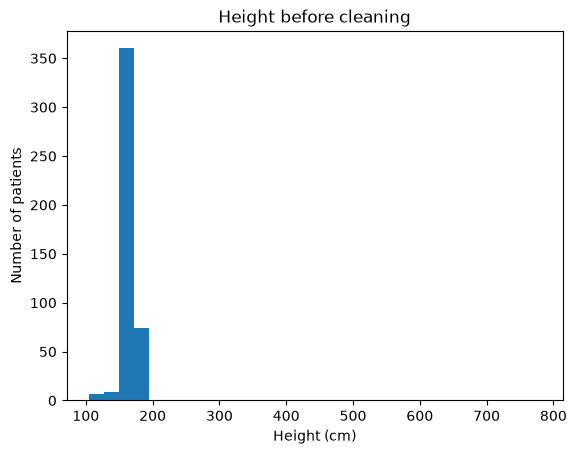

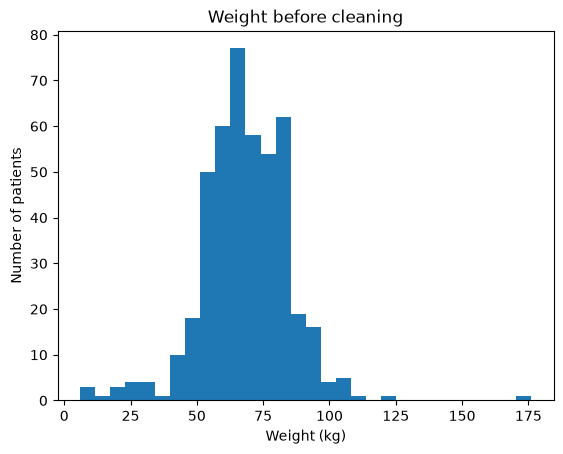

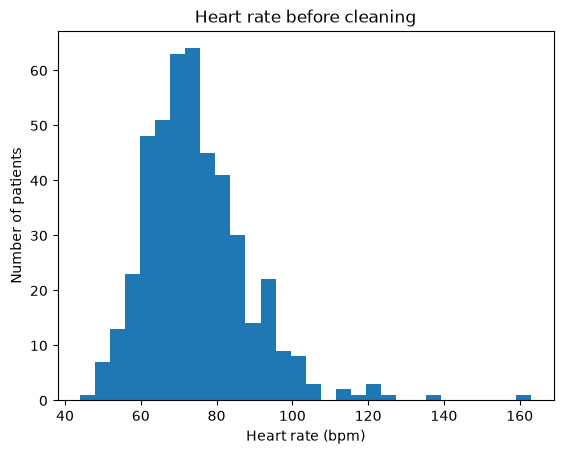

age raw range: (np.int64(0), np.int64(83)) clean range: (np.int64(3), np.int64(83))
height raw range: (np.int64(105), np.int64(780)) clean range: (np.int64(105), np.int64(190))
weight raw range: (np.int64(6), np.int64(176)) clean range: (np.int64(12), np.int64(176))
heart_rate raw range: (np.float64(44.0), np.float64(163.0)) clean range: (np.float64(44.0), np.float64(124.0))


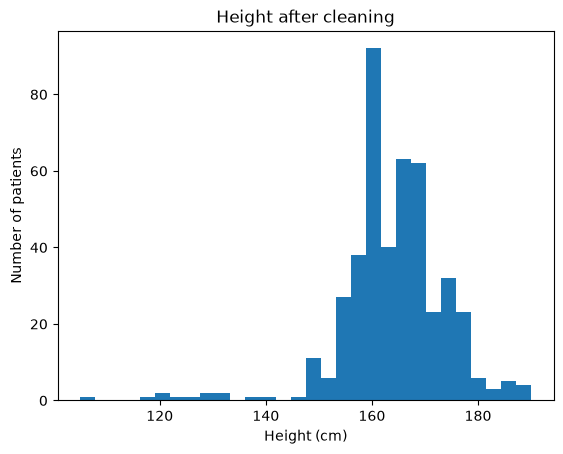

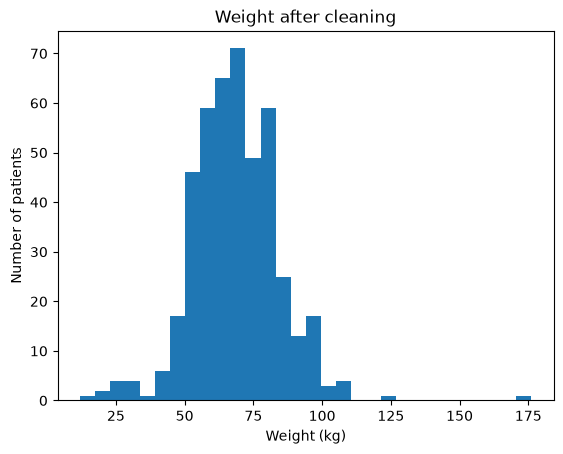

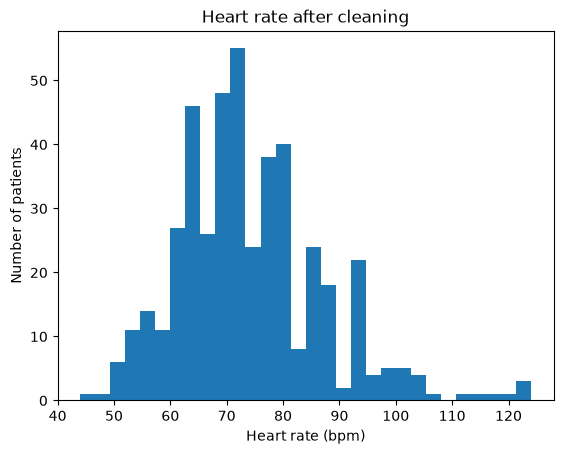

In [29]:
plt.hist(df_etl_clean["age"].dropna(), bins=25)
plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.title("Distribution of age")
plt.show()
# Raw distributions
for col, label, unit in [
    ("height", "Height", "cm"),
    ("weight", "Weight", "kg"),
    ("heart_rate", "Heart rate", "bpm"),
]:
    plt.hist(df_original[col].dropna(), bins=30)
    plt.title(f"{label} before cleaning")
    plt.xlabel(f"{label} ({unit})")
    plt.ylabel("Number of patients")
    plt.show()
# Compare raw and cleaned ranges
for col in ["age", "height", "weight", "heart_rate"]:
    print(
    col,
    "raw range:",
    (df_original[col].min(), df_original[col].max()),
    "clean range:",
    (df_etl_clean[col].min(), df_etl_clean[col].max()),
)
# Replot the cleaned measurements
for col, label, unit in [
    ("height", "Height", "cm"),
    ("weight", "Weight", "kg"),
    ("heart_rate", "Heart rate", "bpm"),
]:
    plt.hist(df_etl_clean[col].dropna(), bins=30)
    plt.title(f"{label} after cleaning")
    plt.xlabel(f"{label} ({unit})")
    plt.ylabel("Number of patients")
    plt.show()

C:\Users\elsto\AppData\Local\Temp\ipykernel_57360\2764630356.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


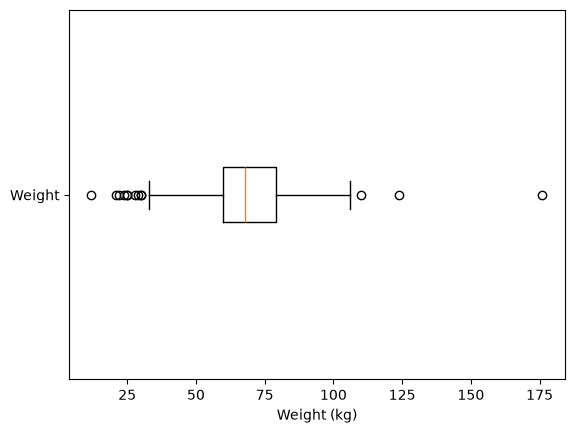

In [30]:
# Weight boxplot
plt.boxplot(
    df_etl_clean["weight"].dropna(),
    vert=False,
    tick_labels=["Weight"]
)
plt.xlabel("Weight (kg)")
plt.show()



In [31]:
# IQR flags for demographic variables
def iqr_flag(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (
    (series < q1 - 1.5 * iqr)
    | (series > q3 + 1.5 * iqr)
)
age_flag = iqr_flag(df_etl_clean["age"])
height_flag = iqr_flag(df_etl_clean["height"])
weight_flag = iqr_flag(df_etl_clean["weight"])

demographic_flags = age_flag | height_flag | weight_flag

print(
    df_etl_clean.loc[
    demographic_flags,
    ["age", "sex", "height", "weight", "class"]
    ]
    .sort_values(["age", "height", "weight"])
    .to_string()
    )
# Heart rate checked separately with a z-score
mean_hr = df_etl_clean["heart_rate"].mean()
std_hr = df_etl_clean["heart_rate"].std()
z_hr = (
df_etl_clean["heart_rate"] - mean_hr
) / std_hr
print("Heart-rate values with |z| > 3:")
print(
df_etl_clean.loc[
z_hr.abs() > 3,
["age", "sex", "heart_rate", "class"]
]
)

     age  sex  height  weight  class
316    3    0     105      12      5
420    7    0     119      21      9
399    7    1     127      22      5
294    7    1     130      30     10
375    8    0     120      28     10
425    8    1     130      24     16
397    9    0     120      25     14
112    9    0     132      33      1
207   11    1     124      25     10
426   11    0     138      29     10
428   11    0     140      42     10
195   13    1     133      30     16
342   20    0     186      66     10
444   37    0     190      85     10
328   42    0     188      91     16
419   51    0     186      95      1
210   53    0     169     176      2
305   62    1     170     110      2
251   66    1     160     124      1
0     75    0     190      80      8
4     75    0     190      80      7
Heart-rate values with |z| > 3:
     age  sex  heart_rate  class
240   49    1       115.0     15
316    3    0       124.0      5
375    8    0       123.0     10
383   53    1       11

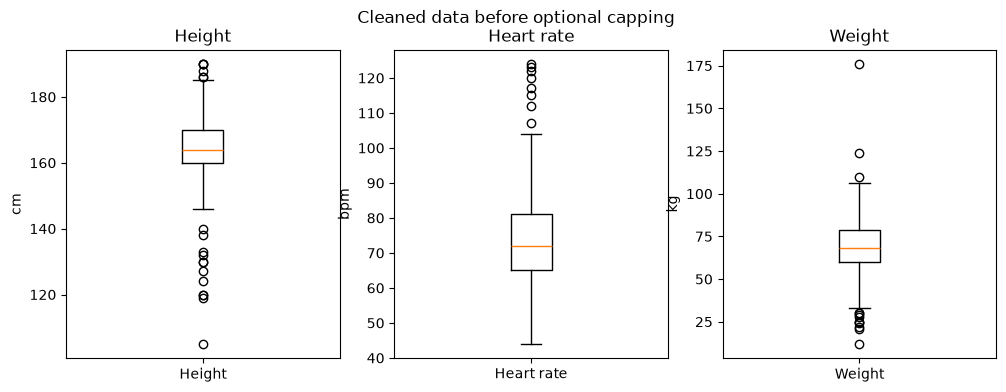

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].boxplot(df_etl_clean["height"].dropna(), tick_labels=["Height"])
axes[0].set_title("Height"); axes[0].set_ylabel("cm")
axes[1].boxplot(df_etl_clean["heart_rate"].dropna(), tick_labels=["Heart rate"])
axes[1].set_title("Heart rate"); axes[1].set_ylabel("bpm")
axes[2].boxplot(df_etl_clean["weight"].dropna(), tick_labels=["Weight"])
axes[2].set_title("Weight"); axes[2].set_ylabel("kg")
plt.suptitle("Cleaned data before optional capping")
plt.show()

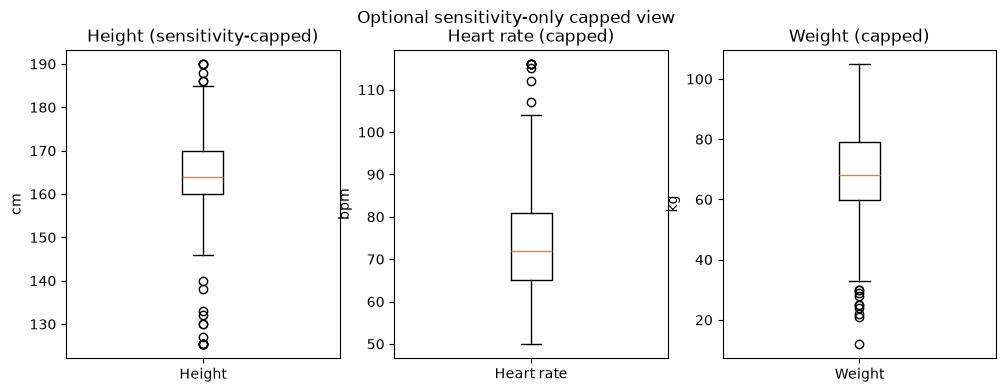

In [33]:
df_sensitivity = df_etl_clean.copy(deep=True)
df_sensitivity["height_capped"] = (
df_sensitivity["height"].clip(
lower=df_sensitivity["height"].quantile(0.01)
)
)
df_sensitivity["heart_rate_capped"] = (
df_sensitivity["heart_rate"].clip(
lower=df_sensitivity["heart_rate"].quantile(0.01),
upper=df_sensitivity["heart_rate"].quantile(0.99)
)
)
df_sensitivity["weight_capped"] = (
df_sensitivity["weight"].clip(
upper=df_sensitivity["weight"].quantile(0.99)
)
)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].boxplot(
df_sensitivity["height_capped"].dropna(),
tick_labels=["Height"]
)
axes[0].set_title("Height (sensitivity-capped)")
axes[0].set_ylabel("cm")
axes[1].boxplot(
df_sensitivity["heart_rate_capped"].dropna(),
tick_labels=["Heart rate"]
)
axes[1].set_title("Heart rate (capped)")
axes[1].set_ylabel("bpm")
axes[2].boxplot(
df_sensitivity["weight_capped"].dropna(),
tick_labels=["Weight"]
)
axes[2].set_title("Weight (capped)")
axes[2].set_ylabel("kg")
plt.suptitle("Optional sensitivity-only capped view")
plt.show()

sex
0    0.580000
1    0.354839
Name: arrhythmia_present, dtype: float64


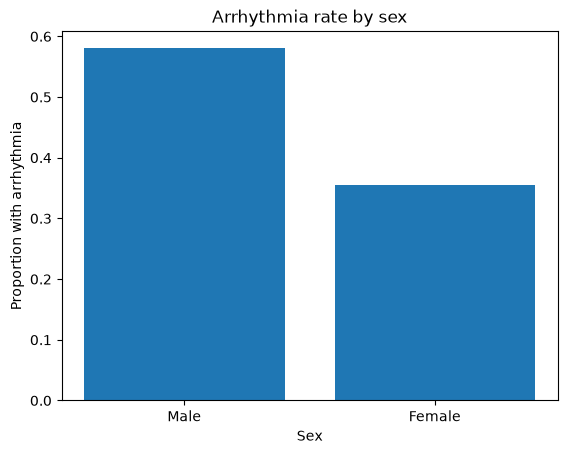

               age  height  weight  qrs_duration  pr_interval  qt_interval  \
age           1.00    0.22    0.35         -0.01         0.03         0.14   
height        0.22    1.00    0.58          0.04         0.07         0.02   
weight        0.35    0.58    1.00          0.09         0.12         0.04   
qrs_duration -0.01    0.04    0.09          1.00         0.02         0.22   
pr_interval   0.03    0.07    0.12          0.02         1.00         0.07   
qt_interval   0.14    0.02    0.04          0.22         0.07         1.00   
heart_rate   -0.12   -0.18   -0.08          0.01        -0.04        -0.62   

              heart_rate  
age                -0.12  
height             -0.18  
weight             -0.08  
qrs_duration        0.01  
pr_interval        -0.04  
qt_interval        -0.62  
heart_rate          1.00  
Strongest absolute correlation: ('qt_interval', 'heart_rate') -0.62


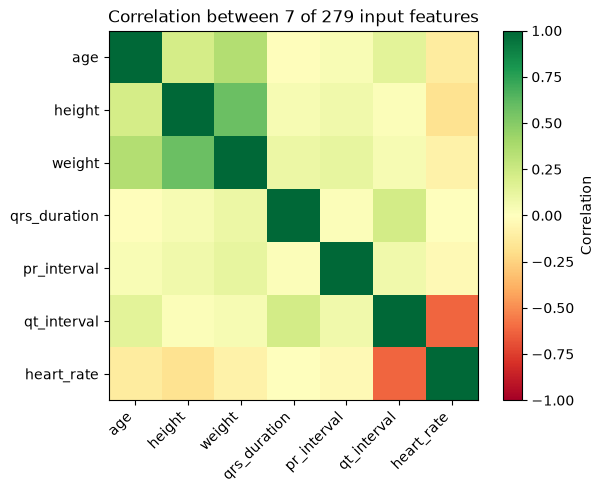

In [34]:
import numpy as np
# Arrhythmia rate by sex
rate = (
df_etl_clean
.groupby("sex", observed=False)["arrhythmia_present"]
.mean()
)
print(rate)
sex_labels = {0: "Male", 1: "Female"}
labels = [sex_labels[int(value)] for value in rate.index]
plt.bar(labels, rate.values)
plt.xlabel("Sex")
plt.ylabel("Proportion with arrhythmia")
plt.title("Arrhythmia rate by sex")
plt.show()
# Correlation heatmap
num_cols = [
"age", "height", "weight", "qrs_duration",
"pr_interval", "qt_interval", "heart_rate"
]
corr_matrix = df_etl_clean[num_cols].corr()
print(corr_matrix.round(2))
upper_triangle = corr_matrix.where(
np.triu(
np.ones(corr_matrix.shape),
k=1
).astype(bool)
)
strongest_pair = upper_triangle.abs().stack().idxmax()
print(
"Strongest absolute correlation:",
strongest_pair,
round(
corr_matrix.loc[
strongest_pair[0],
strongest_pair[1]
],
2
)
)
plt.imshow(
    corr_matrix,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)
plt.xticks(
    range(len(num_cols)),
num_cols,
rotation=45,
ha="right"
)
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(label="Correlation")
plt.title("Correlation between 7 of 279 input features")
plt.show()

Patients per class:
class
1     244
2      44
3      15
4      15
5      10
6      25
7       3
8       2
9       9
10     50
14      4
15      5
16     22
Name: count, dtype: int64
Mean profile per class:
       p_interval  qrs_duration  pr_interval  qt_interval  t_interval  \
class                                                                   
1            92.2          84.3        157.2        367.2       163.0   
2            87.5          89.8        153.0        369.6       190.7   
3            98.4          93.3        163.2        355.5       201.8   
4            94.0          89.9        160.4        352.1       170.0   
5            88.2          89.6        164.5        311.9       156.8   
6            80.0          83.2        158.0        393.2       152.9   
7            98.0          96.3        190.7        365.3       185.3   
8           101.5          98.5        183.0        368.0       185.0   
9            90.3         154.4        158.4        439.4       

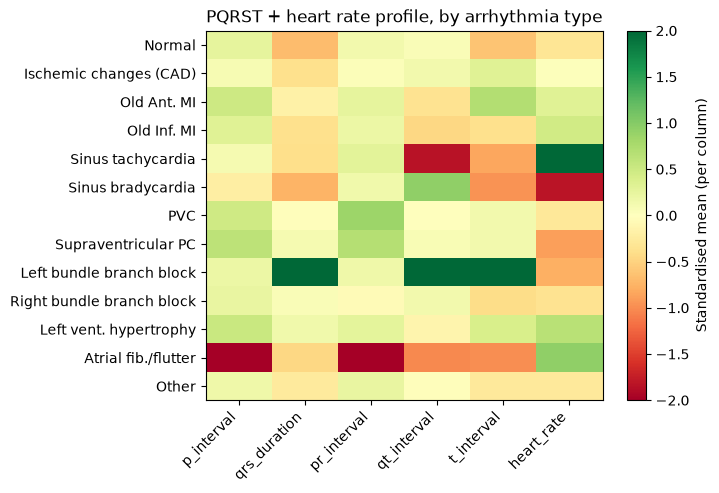

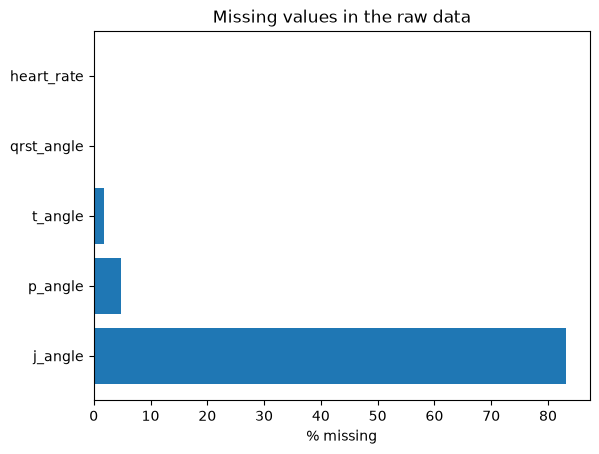

In [35]:
class_names = {
1: "Normal",
2: "Ischemic changes (CAD)",
3: "Old Ant. MI",
4: "Old Inf. MI",
5: "Sinus tachycardia",
6: "Sinus bradycardia",
7: "PVC",
8: "Supraventricular PC",
9: "Left bundle branch block",
10: "Right bundle branch block",
11: "1st degree AV block",
12: "2nd degree AV block",
13: "3rd degree AV block",
14: "Left vent. hypertrophy",
15: "Atrial fib./flutter",
16: "Other",
}
pqrst_cols = [
"p_interval", "qrs_duration", "pr_interval",
"qt_interval", "t_interval", "heart_rate"
]
class_counts = (
df_etl_clean["class"]
.value_counts()
.sort_index()
)
print("Patients per class:")
print(class_counts)
profile = (
df_etl_clean
.groupby("class")[pqrst_cols]
.mean()
)
print("Mean profile per class:")
print(profile.round(1))
profile_z = (
profile - profile.mean()
) / profile.std()
row_labels = [
class_names[int(c)]
for c in profile_z.index
]
plt.imshow(
profile_z.values,
cmap="RdYlGn",
vmin=-2,
vmax=2,
aspect="auto"
)
plt.xticks(
range(len(pqrst_cols)),
pqrst_cols,
rotation=45,
ha="right"
)
plt.yticks(range(len(profile_z)), row_labels)
plt.colorbar(label="Standardised mean (per column)")
plt.title("PQRST + heart rate profile, by arrhythmia type")
plt.show()
# Missingness in the raw data
miss = (
df_original
.isna()
.mean()
.sort_values(ascending=False)
)
miss = miss[miss > 0] * 100
plt.barh(miss.index.astype(str), miss.values)
plt.xlabel("% missing")
plt.title("Missing values in the raw data")
plt.show()

Mean heart rate by class:
class
6      53.920000
8      66.000000
9      67.444444
10     72.820000
1      73.213115
7      73.666667
16     73.863636
2      77.681818
3      81.333333
4      83.133333
14     85.500000
15     89.200000
5     106.900000
Name: heart_rate, dtype: float64


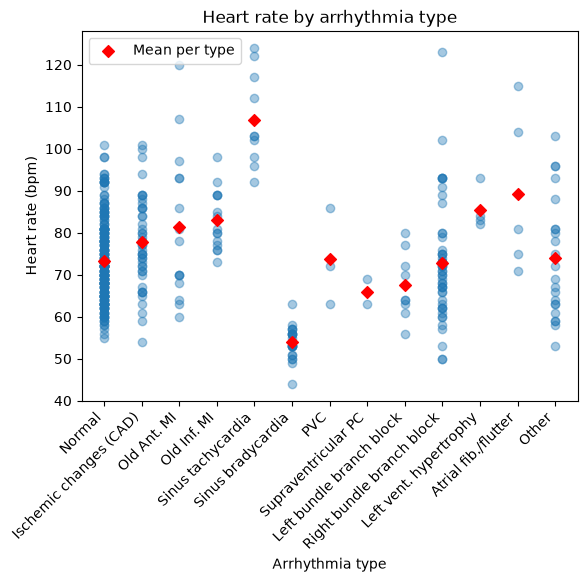

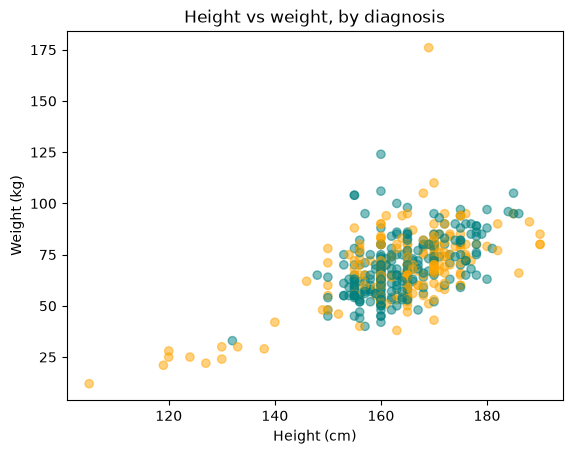

Sample mean age: 46.752232142857146


In [36]:
# Heart rate by arrhythmia type
order = sorted(df_etl_clean["class"].unique())
x_pos = df_etl_clean["class"].map(
{c: i for i, c in enumerate(order)}
)
plt.scatter(
x_pos,
df_etl_clean["heart_rate"],
alpha=0.4
)
means = (
df_etl_clean
.groupby("class")["heart_rate"]
.mean()
)
print("Mean heart rate by class:")
print(means.sort_values())
plt.scatter(
range(len(order)),
[means[c] for c in order],
color="red",
marker="D",
label="Mean per type"
)
plt.xticks(
range(len(order)),
[class_names[c] for c in order],
rotation=45,
ha="right"
)
plt.xlabel("Arrhythmia type")
plt.ylabel("Heart rate (bpm)")
plt.title("Heart rate by arrhythmia type")
plt.legend()
plt.show()
# Height versus weight by diagnosis
colors = df_etl_clean["arrhythmia_present"].map(
{True: "orange", False: "teal"}
)
plt.scatter(
df_etl_clean["height"],
df_etl_clean["weight"],
c=colors,
alpha=0.5
)
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs weight, by diagnosis")
plt.show()
# Age versus binary arrhythmia outcome with jitter
jitter = (
df_etl_clean["arrhythmia_present"].astype(int)
+ np.random.uniform(
-0.08,
0.08,
len(df_etl_clean)
)
)
print(
"Sample mean age:",
df_etl_clean["age"].mean()
)


In [37]:
%pip install scipy
from scipy import stats
a = df_etl_clean.loc[
    df_etl_clean["arrhythmia_present"],
    "heart_rate"
]
b = df_etl_clean.loc[
    ~df_etl_clean["arrhythmia_present"],
    "heart_rate"
]
t, p = stats.ttest_ind(
    a,
    b,
    equal_var=False
)

print("Mean with arrhythmia:", a.mean())
print("Mean without arrhythmia:", b.mean())
print(f"t = {t:.2f}, p = {p:.4f}")

if p < 0.05:
    print(
    "Reject H0: the mean heart rates "
    "differ significantly."
)
else:
    print(
"Fail to reject H0: no significant "
"mean difference was detected."
)


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\elsto\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Mean with arrhythmia: 75.07843137254902
Mean without arrhythmia: 73.21311475409836
t = 1.46, p = 0.1441
Fail to reject H0: no significant mean difference was detected.


In [38]:
table = pd.crosstab(
    df_etl_clean["sex"],
    df_etl_clean["arrhythmia_present"]
)
print(table)

chi2, p, dof, expected = (
    stats.chi2_contingency(table)
)
print(f"chi2 = {chi2:.2f}, p = {p:.6f}")
print("Degrees of freedom:", dof)
print("Expected counts:")
print(expected)
if p < 0.05:
    print(
    "Reject H0: sex and diagnosis are "
    "associated in this sample."
)
else:
    print(
    "Fail to reject H0: no significant "
    "association was detected."
)

arrhythmia_present  False  True 
sex                             
0                      84    116
1                     160     88
chi2 = 21.73, p = 0.000003
Degrees of freedom: 1
Expected counts:
[[108.92857143  91.07142857]
 [135.07142857 112.92857143]]
Reject H0: sex and diagnosis are associated in this sample.


In [39]:
print("LAB4")

LAB4


In [40]:
print(df_etl_clean.shape)

(448, 281)


In [41]:
clinical_cols = ["age", "sex", "height", "weight", "qrs_duration",
"pr_interval", "qt_interval", "t_interval", "p_interval",
"qrs_angle", "t_angle", "p_angle", "qrst_angle", "bmi"]
correlations = df_etl_clean[clinical_cols + ["heart_rate"]].corr()["heart_rate"]
print(correlations.abs().sort_values(ascending=False))

heart_rate      1.000000
qt_interval     0.617472
height          0.176618
p_angle         0.125856
age             0.122496
weight          0.082403
sex             0.080319
t_angle         0.074463
p_interval      0.063117
t_interval      0.043729
qrs_angle       0.043620
bmi             0.038837
qrst_angle      0.038037
pr_interval     0.037148
qrs_duration    0.005194
Name: heart_rate, dtype: float64


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
X = df_etl_clean[["qt_interval"]]
y = df_etl_clean["heart_rate"]
print("X:", X.shape, " y:", y.shape)

X: (448, 1)  y: (448,)


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (313, 1)  Test: (135, 1)


In [44]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained on", len(X_train), "patients")

Model trained on 313 patients


In [45]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [-0.24785936]
Intercept: 165.1525239758605


In [46]:
predictions = model.predict(X_test)
comparison = pd.DataFrame({"actual": y_test, "predicted": predictions})
print(comparison.head())

     actual  predicted
285    72.0  70.470248
296    73.0  70.470248
117    93.0  77.658169
346    63.0  72.453123
70     69.0  76.914591


In [47]:
r2 = r2_score(y_test, predictions)
print("R²:", round(r2, 2))

R²: 0.34


In [48]:
target = df_etl_clean["arrhythmia_present"].astype(int)
target_corr = df_etl_clean[clinical_cols].corrwith(target).abs()
print(target_corr.sort_values(ascending=False))

qrs_duration    0.333656
sex             0.224763
t_interval      0.220525
p_interval      0.090729
qrs_angle       0.090267
pr_interval     0.047034
qrst_angle      0.037458
age             0.035833
bmi             0.030163
qt_interval     0.026888
weight          0.013643
height          0.010807
t_angle         0.001403
p_angle         0.000545
dtype: float64


In [49]:
feature_corr = df_etl_clean[clinical_cols].corr().abs()
print(feature_corr.round(2))

               age   sex  height  weight  qrs_duration  pr_interval  \
age           1.00  0.07    0.22    0.35          0.01         0.03   
sex           0.07  1.00    0.49    0.28          0.34         0.05   
height        0.22  0.49    1.00    0.58          0.04         0.07   
weight        0.35  0.28    0.58    1.00          0.09         0.12   
qrs_duration  0.01  0.34    0.04    0.09          1.00         0.02   
pr_interval   0.03  0.05    0.07    0.12          0.02         1.00   
qt_interval   0.14  0.07    0.02    0.04          0.22         0.07   
t_interval    0.01  0.19    0.05    0.14          0.40         0.07   
p_interval    0.09  0.09    0.13    0.12          0.05         0.67   
qrs_angle     0.24  0.08    0.11    0.15          0.14         0.01   
t_angle       0.01  0.14    0.04    0.04          0.03         0.12   
p_angle       0.07  0.00    0.04    0.06          0.04         0.05   
qrst_angle    0.27  0.04    0.12    0.19          0.07         0.03   
bmi   

In [50]:
threshold = 0.7
to_drop = set()
for i in range(len(clinical_cols)):
    for j in range(i + 1, len(clinical_cols)):
     col_i, col_j = clinical_cols[i], clinical_cols[j]
    if feature_corr.loc[col_i, col_j] > threshold:
        if target_corr[col_i] >= target_corr[col_j]:
           to_drop.add(col_j)
    else:
        to_drop.add(col_i)
selected_features = [c for c in clinical_cols if c not in to_drop]
print("Dropped as redundant:", sorted(to_drop))
print("Selected features:", selected_features)

Dropped as redundant: ['age', 'height', 'p_angle', 'p_interval', 'pr_interval', 'qrs_angle', 'qrs_duration', 'qrst_angle', 'qt_interval', 'sex', 't_angle', 't_interval']
Selected features: ['weight', 'bmi']


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
X = df_etl_clean[selected_features]
y = df_etl_clean["arrhythmia_present"]
print("X:", X.shape)
print(y.value_counts())

X: (448, 2)
arrhythmia_present
False    244
True     204
Name: count, dtype: int64


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train arrhythmia rate:", round(y_train.mean(), 2))
print("Test arrhythmia rate:", round(y_test.mean(), 2))

Train: (313, 2)  Test: (135, 2)
Train arrhythmia rate: 0.46
Test arrhythmia rate: 0.45


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train arrhythmia rate:", round(y_train.mean(), 2))
print("Test arrhythmia rate:", round(y_test.mean(), 2))

Train: (313, 2)  Test: (135, 2)
Train arrhythmia rate: 0.46
Test arrhythmia rate: 0.45


In [54]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)
probabilities = model.predict_proba(X_test)
print(probabilities[:5])

[[0.56864881 0.43135119]
 [0.51124362 0.48875638]
 [0.55896308 0.44103692]
 [0.55608086 0.44391914]
 [0.57627469 0.42372531]]


In [55]:
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", round(accuracy, 2))

Accuracy: 0.56


In [56]:
baseline_guess = y_train.value_counts().idxmax()
baseline_accuracy = (y_test == baseline_guess).mean()
print("Baseline:", round(baseline_accuracy, 2))

Baseline: 0.55


In [57]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[74  0]
 [60  1]]


In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_etl_clean[selected_features])
print(X_scaled[:3])

[[ 0.71951692 -0.64888757]
 [-0.29754032 -0.37756178]
 [ 1.67300808  1.35538812]]


In [59]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_etl_clean["cluster"] = kmeans.fit_predict(X_scaled)
print(df_etl_clean["cluster"].value_counts())

cluster
1    226
0    222
Name: count, dtype: int64


In [60]:
print(pd.crosstab(df_etl_clean["cluster"], df_etl_clean["arrhythmia_present"]))

arrhythmia_present  False  True 
cluster                         
0                     119    103
1                     125    101
